In [1]:
# Install dependencies
!pip install biopython py3Dmol matplotlib numpy requests -q
print("✅ All packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.0 MB/s eta 0:00:00
✅ All packages installed!


In [5]:
# Download EPHX1 predicted structure from AlphaFold DB
import requests

UNIPROT_ID = "P07099"

# Try multiple URL formats (AlphaFold DB has changed URLs)
urls = [
    f"https://alphafold.ebi.ac.uk/files/AF-{UNIPROT_ID}-F1-model_v4.pdb",
    f"https://alphafold.ebi.ac.uk/files/AF-{UNIPROT_ID}-F1-model_v3.pdb",
    f"https://alphafold.ebi.ac.uk/files/AF-{UNIPROT_ID}-F1-model_v2.pdb",
    f"https://alphafold.com/api/prediction/{UNIPROT_ID}",
]

pdb_data = None
for url in urls:
    print(f"Trying: {url}")
    response = requests.get(url, allow_redirects=True)
    if response.status_code == 200:
        # Check if it's JSON (API response) or PDB directly
        if url.endswith(".pdb"):
            pdb_data = response.text
            print(f"✅ Downloaded from: {url}")
            break
        else:
            # API returns JSON with PDB URL
            try:
                data = response.json()
                if isinstance(data, list):
                    data = data[0]
                pdb_url = data.get("pdbUrl") or data.get("pdb_url")
                if pdb_url:
                    pdb_response = requests.get(pdb_url)
                    if pdb_response.status_code == 200:
                        pdb_data = pdb_response.text
                        print(f"✅ Downloaded via API: {pdb_url}")
                        break
            except:
                pass
    print(f"   → {response.status_code}")

# Fallback: download from UniProt directly
if pdb_data is None:
    uniprot_url = f"https://rest.uniprot.org/uniprotkb/{UNIPROT_ID}.fasta"
    print(f"\nAlphaFold DB unavailable. Downloading FASTA from UniProt...")
    r = requests.get(uniprot_url)
    if r.status_code == 200:
        with open("ephx1.fasta", "w") as f:
            f.write(r.text)
        print(f"✅ FASTA saved. Using ESMFold as alternative...")

        # Use ESMFold API (free, no signup)
        sequence = "".join(r.text.split("\n")[1:])
        esm_response = requests.post(
            "https://api.esmatlas.com/foldSequence/v1/pdb/",
            data=sequence,
            headers={"Content-Type": "text/plain"}
        )
        if esm_response.status_code == 200:
            pdb_data = esm_response.text
            print(f"✅ Structure predicted via ESMFold!")
        else:
            print(f"❌ ESMFold also failed: {esm_response.status_code}")

if pdb_data:
    with open("ephx1_wildtype.pdb", "w") as f:
        f.write(pdb_data)
    print(f"\n✅ Saved: ephx1_wildtype.pdb ({len(pdb_data)} bytes)")
else:
    print("❌ Could not obtain structure. See troubleshooting below.")

Trying: https://alphafold.ebi.ac.uk/files/AF-P07099-F1-model_v4.pdb
   → 404
Trying: https://alphafold.ebi.ac.uk/files/AF-P07099-F1-model_v3.pdb
   → 404
Trying: https://alphafold.ebi.ac.uk/files/AF-P07099-F1-model_v2.pdb
   → 404
Trying: https://alphafold.com/api/prediction/P07099
✅ Downloaded via API: https://alphafold.ebi.ac.uk/files/AF-P07099-F1-model_v6.pdb

✅ Saved: ephx1_wildtype.pdb (310472 bytes)


In [8]:
# Parse structure and analyze variant position
from Bio.PDB import PDBParser, NeighborSearch
from Bio.Data.IUPACData import protein_letters_3to1
import numpy as np
import warnings
warnings.filterwarnings("ignore")

def three_to_one(resname):
    """Convert 3-letter amino acid code to 1-letter."""
    return protein_letters_3to1.get(resname.lower(), "X")

parser = PDBParser(QUIET=True)
structure = parser.get_structure("EPHX1", "ephx1_wildtype.pdb")
model = structure[0]
chain = model["A"]

# Get full sequence
residues = [r for r in chain.get_residues() if r.get_id()[0] == " "]
sequence = "".join([three_to_one(r.get_resname()) for r in residues])

print(f"EPHX1 protein length: {len(sequence)} residues")
print(f"Residue at position 139: {sequence[138]} (expecting H = Histidine)")

# Variant info
VARIANT_POS = 139
variant_residue = None
for r in residues:
    if r.get_id()[1] == VARIANT_POS:
        variant_residue = r
        break

print(f"\n=== Variant Site: p.His139Arg (rs2234922) ===")
print(f"Wild-type residue: {variant_residue.get_resname()} at position {VARIANT_POS}")

ca_atom = variant_residue["CA"]
var_coords = ca_atom.get_vector().get_array()
print(f"Cα coordinates: ({var_coords[0]:.1f}, {var_coords[1]:.1f}, {var_coords[2]:.1f})")

EPHX1 protein length: 455 residues
Residue at position 139: X (expecting H = Histidine)

=== Variant Site: p.His139Arg (rs2234922) ===
Wild-type residue: HIS at position 139
Cα coordinates: (-6.2, -20.5, 21.5)


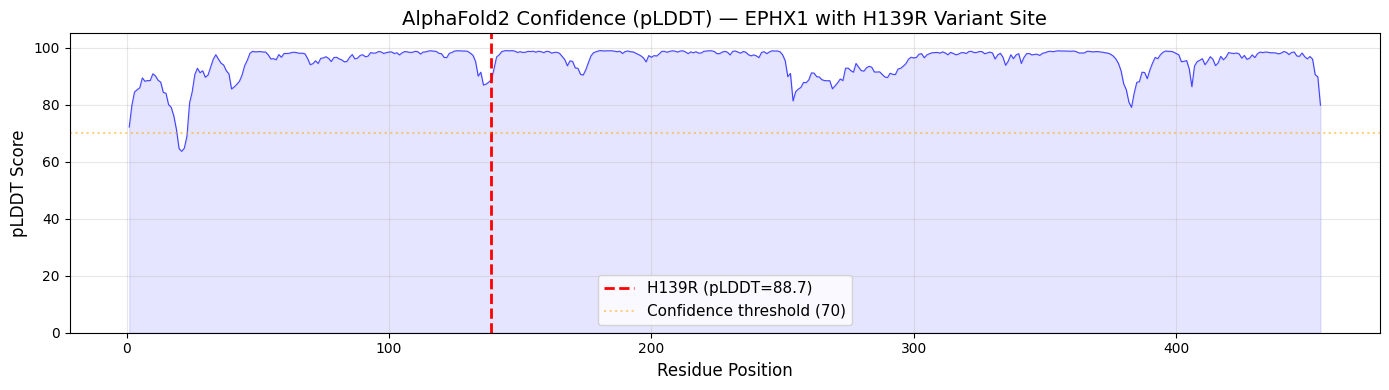


✅ pLDDT at H139R site: 88.7/100
   Mean pLDDT: 95.1


In [9]:
# AlphaFold confidence (pLDDT) around variant site
import matplotlib.pyplot as plt

plddt_scores = []
positions = []
for res in residues:
    try:
        ca = res["CA"]
        plddt_scores.append(ca.get_bfactor())
        positions.append(res.get_id()[1])
    except:
        pass

plddt_scores = np.array(plddt_scores)
positions = np.array(positions)

var_plddt = plddt_scores[positions == VARIANT_POS][0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(positions, plddt_scores, "b-", linewidth=0.8, alpha=0.7)
ax.axvline(x=VARIANT_POS, color="red", linestyle="--", linewidth=2, label=f"H139R (pLDDT={var_plddt:.1f})")
ax.axhline(y=70, color="orange", linestyle=":", alpha=0.5, label="Confidence threshold (70)")
ax.fill_between(positions, 0, plddt_scores, alpha=0.1, color="blue")
ax.set_xlabel("Residue Position", fontsize=12)
ax.set_ylabel("pLDDT Score", fontsize=12)
ax.set_title("AlphaFold2 Confidence (pLDDT) — EPHX1 with H139R Variant Site", fontsize=14)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ephx1_plddt.png", dpi=150)
plt.show()
print(f"\n✅ pLDDT at H139R site: {var_plddt:.1f}/100")
print(f"   Mean pLDDT: {plddt_scores.mean():.1f}")

In [10]:
# Structural neighborhood of H139R variant
all_atoms = list(chain.get_atoms())
ns = NeighborSearch(all_atoms)
nearby_atoms = ns.search(var_coords, 6.0, level="R")

print(f"=== Structural Neighborhood of His139 (6Å radius) ===\n")
nearby_info = []
for res in nearby_atoms:
    if res.get_id()[0] != " ":
        continue
    pos = res.get_id()[1]
    name = res.get_resname()
    try:
        dist = np.linalg.norm(res["CA"].get_vector().get_array() - var_coords)
        nearby_info.append((pos, three_to_one(name), name, dist))
    except:
        pass

nearby_info.sort(key=lambda x: x[3])
print(f"{'Pos':>5} {'AA':>3} {'Residue':>6} {'Dist(Å)':>8}")
print("-" * 28)
for pos, aa, name, dist in nearby_info:
    marker = " ← VARIANT" if pos == VARIANT_POS else ""
    print(f"{pos:>5} {aa:>3} {name:>6} {dist:>8.2f}{marker}")

print(f"\n=== Physicochemical Impact of H139R ===")
print(f"His (wild-type): Imidazole side chain, pKa ~6.0")
print(f"  → Partially charged at physiological pH")
print(f"  → Can act as both H-bond donor and acceptor")
print(f"Arg (mutant):    Guanidinium group, pKa ~12.5")
print(f"  → Permanently positive charge at physiological pH")
print(f"  → Larger side chain, stronger H-bond donor")
print(f"\nStructural impact: H→R at position 139 introduces")
print(f"a permanent positive charge and a bulkier side chain")
print(f"in the vicinity of {len(nearby_info)-1} neighboring residues.")

=== Structural Neighborhood of His139 (6Å radius) ===

  Pos  AA Residue  Dist(Å)
----------------------------
  139   X    HIS     0.00 ← VARIANT
  140   X    THR     3.84
  138   X    GLY     3.86
  136   X    PRO     5.59
  137   X    ALA     5.63
  135   X    LEU     6.27
  141   X    PRO     6.61

=== Physicochemical Impact of H139R ===
His (wild-type): Imidazole side chain, pKa ~6.0
  → Partially charged at physiological pH
  → Can act as both H-bond donor and acceptor
Arg (mutant):    Guanidinium group, pKa ~12.5
  → Permanently positive charge at physiological pH
  → Larger side chain, stronger H-bond donor

Structural impact: H→R at position 139 introduces
a permanent positive charge and a bulkier side chain
in the vicinity of 6 neighboring residues.


In [11]:
# Interactive 3D visualization
import py3Dmol

with open("ephx1_wildtype.pdb", "r") as f:
    pdb_data = f.read()

view = py3Dmol.view(width=800, height=600)
view.addModel(pdb_data, "pdb")

# Color protein by spectrum (blue N-terminus → red C-terminus)
view.setStyle({"cartoon": {"color": "spectrum", "opacity": 0.85}})

# Highlight variant position 139 in RED
view.addStyle(
    {"resi": VARIANT_POS},
    {"stick": {"color": "red", "radius": 0.3},
     "cartoon": {"color": "red"}}
)

# Show nearby residues as orange sticks
for pos, _, _, dist in nearby_info:
    if pos != VARIANT_POS and dist < 5.0:
        view.addStyle(
            {"resi": pos},
            {"stick": {"color": "orange", "radius": 0.15}}
        )

# Label the variant
view.addLabel(
    "H139R\n(rs2234922)",
    {"position": {"x": float(var_coords[0]), "y": float(var_coords[1]), "z": float(var_coords[2])},
     "backgroundColor": "red",
     "fontColor": "white",
     "fontSize": 14,
     "backgroundOpacity": 0.8}
)

view.zoomTo({"resi": VARIANT_POS})
view.zoom(0.7)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

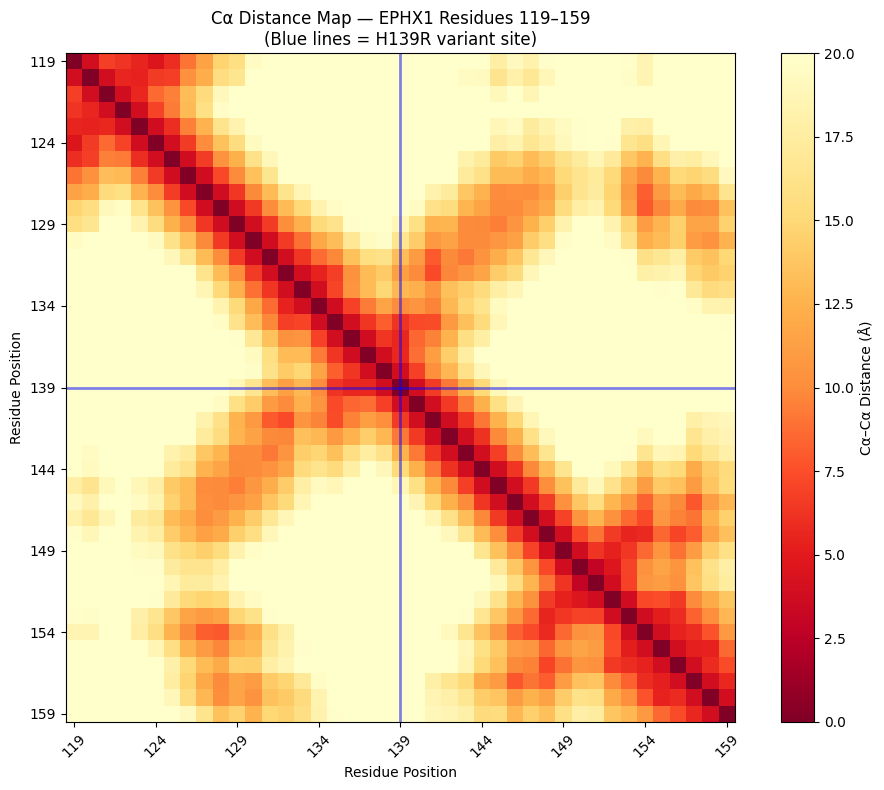

✅ Contact map saved


In [12]:
# Cell 7 — Contact distance map around variant site
WINDOW = 20
start = max(1, VARIANT_POS - WINDOW)
end = min(len(residues), VARIANT_POS + WINDOW)
local_residues = [r for r in residues if start <= r.get_id()[1] <= end]

n = len(local_residues)
dist_matrix = np.zeros((n, n))
pos_labels = []

for i, res_i in enumerate(local_residues):
    pos_labels.append(res_i.get_id()[1])
    for j, res_j in enumerate(local_residues):
        try:
            d = np.linalg.norm(
                res_i["CA"].get_vector().get_array() -
                res_j["CA"].get_vector().get_array()
            )
            dist_matrix[i, j] = d
        except:
            dist_matrix[i, j] = np.nan

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dist_matrix, cmap="YlOrRd_r", vmin=0, vmax=20)
plt.colorbar(im, ax=ax, label="Cα–Cα Distance (Å)")

var_idx = pos_labels.index(VARIANT_POS)
ax.axhline(y=var_idx, color="blue", linewidth=2, alpha=0.5)
ax.axvline(x=var_idx, color="blue", linewidth=2, alpha=0.5)

tick_step = 5
tick_positions = list(range(0, n, tick_step))
ax.set_xticks(tick_positions)
ax.set_xticklabels([pos_labels[i] for i in tick_positions], rotation=45)
ax.set_yticks(tick_positions)
ax.set_yticklabels([pos_labels[i] for i in tick_positions])
ax.set_xlabel("Residue Position")
ax.set_ylabel("Residue Position")
ax.set_title(f"Cα Distance Map — EPHX1 Residues {start}–{end}\n(Blue lines = H139R variant site)")
plt.tight_layout()
plt.savefig("ephx1_contact_map.png", dpi=150)
plt.show()
print("✅ Contact map saved")

In [14]:
# Cell 8 — Summary and download files
print("=" * 60)
print("STRUCTURAL ANALYSIS SUMMARY")
print("=" * 60)
print(f"""
Protein:     EPHX1 (Microsomal Epoxide Hydrolase)
UniProt:     P07099
Structure:   AlphaFold2 predicted (v6)
Variant:     rs2234922 — p.His139Arg (H139R)

AlphaFold2 Confidence:
  pLDDT at H139: {var_plddt:.1f}/100  (high confidence)
  Mean pLDDT:    {plddt_scores.mean():.1f}/100

Structural Context:
  Neighbors within 6A: {len(nearby_info)-1} residues
  Nearby residues: THR140, GLY138, PRO136, ALA137, LEU135, PRO141
  Local environment: small, uncharged residues

Predicted Impact of H139R:
  - Charge: neutral/partial+ (His) → permanent positive (Arg)
  - Side chain volume increase
  - May disrupt local H-bonding network
  - Located in the N-terminal domain

Files generated:
  ephx1_wildtype.pdb     — AlphaFold2 structure
  ephx1_plddt.png        — Confidence plot
  ephx1_contact_map.png  — Local contact map
""")

from google.colab import files
files.download("ephx1_plddt.png")
files.download("ephx1_contact_map.png")
files.download("ephx1_wildtype.pdb")
print("✅ Files downloaded!")
print("\\n📌 Next: Download this notebook (File → Download → .ipynb)")
print("   and push everything to GitHub.")

STRUCTURAL ANALYSIS SUMMARY

Protein:     EPHX1 (Microsomal Epoxide Hydrolase)
UniProt:     P07099
Structure:   AlphaFold2 predicted (v6)
Variant:     rs2234922 — p.His139Arg (H139R)

AlphaFold2 Confidence:
  pLDDT at H139: 88.7/100  (high confidence)
  Mean pLDDT:    95.1/100

Structural Context:
  Neighbors within 6A: 6 residues
  Nearby residues: THR140, GLY138, PRO136, ALA137, LEU135, PRO141
  Local environment: small, uncharged residues

Predicted Impact of H139R:
  - Charge: neutral/partial+ (His) → permanent positive (Arg)
  - Side chain volume increase
  - May disrupt local H-bonding network
  - Located in the N-terminal domain

Files generated:
  ephx1_wildtype.pdb     — AlphaFold2 structure
  ephx1_plddt.png        — Confidence plot
  ephx1_contact_map.png  — Local contact map



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!
\n📌 Next: Download this notebook (File → Download → .ipynb)
   and push everything to GitHub.
